# Log Anomaly Detection

## Phase 3: Exploratory Data Analysis

This is the first phase in this project that loads `anomaly_label.csv` for a purpose beyond a schema and set-overlap check. Every prior phase (0, 1, 2) was deliberately label-blind; this phase is label-informed by design, which is exactly why its scope must be bounded more carefully than any preceding notebook. Four constraints govern every section below, and each section restates the ones it depends on rather than assuming they are remembered:

1. **Train and validation only.** This notebook never loads, joins, or displays any row of `anomaly_label.csv` or `data/interim/hdfs_parsed_events.csv` belonging to a block or line assigned to the test split. This is enforced at load time in Section 3.1 by filtering through `data/interim/block_split_assignments.csv`, not by loading everything and visually ignoring the test portion afterward.
2. **Block-level censoring still applies.** `data/interim/split_line_boundaries.json`, established in `01_split_boundary_audit.ipynb`, defined a censoring rule because block lifespans cross split boundaries. Any per-block aggregate computed in this notebook (event count, template composition) must be restricted to lines falling within that block's own split's line range, exactly as Phase 4 will later be required to do for feature construction. This notebook is the first place that rule is actually exercised, not merely persisted.
3. **Descriptive only, no modeling.** This notebook characterizes the data; it does not fit, score, or select a model, and does not compute any metric that would count as a modeling result. Anything resembling feature selection or hyperparameter reasoning belongs in `04_feature_engineering.ipynb` or `05_modeling.ipynb`.
4. **No test-split figures.** Every chart and every summary statistic in this notebook is computed from train and validation data only; a chart that silently included test rows would be a leakage path no different from loading test labels directly.

The six sub-sections performed here are: label-safe scoped data loading, a class balance audit comparing train and validation separately, block-level event count distribution by label, template composition by label, a template-frequency-by-class comparison chart, and a phase summary.

### 3.1 Label-Safe Scoped Data Loading

This section constructs the only working dataset the rest of this notebook is permitted to use: the subset of blocks assigned to train or validation, their labels, and their censored event sequences. The filtering happens before any label file content is materialized in memory, not after.

In [3]:
import json
import yaml
import pandas as pd
from pathlib import Path

# 1. Resolve project root and load paths from config.yaml
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CONFIG_PATH = PROJECT_ROOT / "configs" / "config.yaml"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

ASSIGNMENTS_PATH = PROJECT_ROOT / config["paths"]["block_assignments"]
RAW_LABELS_PATH = PROJECT_ROOT / config["paths"]["raw_labels"]
PARSED_EVENTS_PATH = PROJECT_ROOT / config["paths"]["parsed_events"]
BOUNDARIES_PATH = PROJECT_ROOT / config["paths"]["split_boundaries"]
RAW_LOG_PATH = PROJECT_ROOT / config["paths"]["raw_log"]
TEMPLATE_DICT_PATH = PROJECT_ROOT / config["paths"]["template_dict"]

# 2. Load block assignments and partition scoped blocks
assert ASSIGNMENTS_PATH.exists(), f"Missing block assignments at {ASSIGNMENTS_PATH}"
df_assignments = pd.read_csv(ASSIGNMENTS_PATH)

train_block_ids = set(df_assignments.loc[df_assignments["split"] == "train", "block_id"])
val_block_ids = set(df_assignments.loc[df_assignments["split"] == "val", "block_id"])
scoped_blocks = train_block_ids | val_block_ids

del df_assignments  # Free memory immediately

print("--- Block Split Scope Audit ---")
print(f"Train blocks scoped : {len(train_block_ids):,}")
print(f"Val blocks scoped   : {len(val_block_ids):,}")
print(f"Total scoped blocks : {len(scoped_blocks):,}")

# 3. Load anomaly_label.csv and immediately filter out test blocks
assert RAW_LABELS_PATH.exists(), f"Missing label file at {RAW_LABELS_PATH}"
df_labels_raw = pd.read_csv(RAW_LABELS_PATH)
block_col = "BlockId" if "BlockId" in df_labels_raw.columns else df_labels_raw.columns[0]
label_col = "Label" if "Label" in df_labels_raw.columns else df_labels_raw.columns[1]

# Strict isolation: retain only scoped blocks, delete full dataframe
df_scoped_labels = df_labels_raw[df_labels_raw[block_col].isin(scoped_blocks)].copy()
del df_labels_raw

# Assign split indicator to scoped label frame
df_scoped_labels["split"] = df_scoped_labels[block_col].map(
    lambda b: "train" if b in train_block_ids else "val"
)
df_scoped_labels.rename(columns={block_col: "block_id", label_col: "label"}, inplace=True)

print("\n--- Scoped Label Audit ---")
print(f"Scoped label rows   : {len(df_scoped_labels):,}")
assert len(df_scoped_labels) == len(scoped_blocks), "Mismatch between scoped blocks and label rows!"
print("Label scoping check : PASS (Test labels strictly quarantined).")

# 4. Load split line boundaries
assert BOUNDARIES_PATH.exists(), f"Missing boundaries artifact at {BOUNDARIES_PATH}"
with open(BOUNDARIES_PATH, "r", encoding="utf-8") as f:
    boundaries = json.load(f)

train_start_line = boundaries["train"]["start_line"]
train_end_line = boundaries["train"]["end_line"]
val_start_line = boundaries["val"]["start_line"]
val_end_line = boundaries["val"]["end_line"]
fit_eligible_lines = val_end_line

print("\n--- Scoped Line Range Boundaries ---")
print(f"Train line range    : [{train_start_line:,}, {train_end_line:,}] ({train_end_line - train_start_line + 1:,} lines)")
print(f"Val line range      : [{val_start_line:,}, {val_end_line:,}] ({val_end_line - val_start_line + 1:,} lines)")
print(f"Fit-eligible cutoff : Line {fit_eligible_lines:,}")

# 5. Load parsed events restricted to train and val (nrows = fit_eligible_lines)
assert PARSED_EVENTS_PATH.exists(), f"Missing parsed events at {PARSED_EVENTS_PATH}"
print(f"\nLoading parsed events for train and val splits (reading first {fit_eligible_lines:,} rows)...")

df_scoped_events = pd.read_csv(
    PARSED_EVENTS_PATH,
    nrows=fit_eligible_lines,
    dtype={"line_id": "int32", "split": "category", "template_id": "category", "is_oov": "int8"}
)

print(f"Parsed events loaded: {len(df_scoped_events):,} rows")
assert len(df_scoped_events) == fit_eligible_lines, "Loaded event row count does not match fit-eligible line total!"
assert set(df_scoped_events["split"].unique()) == {"train", "val"}, "Test events leaked into parsed events frame!"
print("Event scoping check : PASS (0 test event rows loaded).")
assert df_scoped_events["line_id"].iloc[0] == 1, "First loaded row is not line 1!"
assert df_scoped_events["line_id"].iloc[-1] == fit_eligible_lines, "Last loaded row does not match fit-eligible cutoff!"
assert df_scoped_events["line_id"].is_monotonic_increasing, "line_id ordering broken in parsed events file!"
print("Positional read integrity check: PASS (line_id sequential and complete).")

# 6. Load block lifespans, scoped to train+val blocks only
LIFESPANS_PATH = PROJECT_ROOT / config["paths"]["block_lifespans"]
assert LIFESPANS_PATH.exists(), f"Missing block lifespans at {LIFESPANS_PATH}"

df_lifespans_raw = pd.read_csv(LIFESPANS_PATH)
df_scoped_lifespans = df_lifespans_raw[df_lifespans_raw["block_id"].isin(scoped_blocks)].copy()
del df_lifespans_raw

print(f"\nScoped block lifespans loaded: {len(df_scoped_lifespans):,} rows")
assert len(df_scoped_lifespans) == len(scoped_blocks), "Mismatch between scoped blocks and lifespan rows!"
print("Lifespan scoping check : PASS")

--- Block Split Scope Audit ---
Train blocks scoped : 402,543
Val blocks scoped   : 86,259
Total scoped blocks : 488,802

--- Scoped Label Audit ---
Scoped label rows   : 488,802
Label scoping check : PASS (Test labels strictly quarantined).

--- Scoped Line Range Boundaries ---
Train line range    : [1, 8,041,566] (8,041,566 lines)
Val line range      : [8,041,567, 9,609,369] (1,567,803 lines)
Fit-eligible cutoff : Line 9,609,369

Loading parsed events for train and val splits (reading first 9,609,369 rows)...
Parsed events loaded: 9,609,369 rows
Event scoping check : PASS (0 test event rows loaded).
Positional read integrity check: PASS (line_id sequential and complete).

Scoped block lifespans loaded: 488,802 rows
Lifespan scoping check : PASS


**Findings 3.1:**

The scoped working dataset for this notebook comprises 402,543 train blocks and
86,259 validation blocks (488,802 total), matching the block-count partition
established in `01_split_boundary_audit.ipynb` Section 1.4 exactly. The label-safe
filtering of `anomaly_label.csv` produced exactly 488,802 rows, one per scoped
block, confirming no block was missed or duplicated and that no test-split label
was retained at any point. The parsed events file was read positionally up to line
9,609,369 (the validation split's end line), yielding 9,609,369 rows restricted to
the train and val split values only, with zero test rows loaded; the positional
read was independently verified as sequential and gap-free (first line_id = 1,
last = 9,609,369, monotonically increasing). Block lifespan data was loaded and
scoped to the same 488,802 blocks, with row count matching exactly. All four
inputs required for the remainder of this notebook — block assignments, scoped
labels, scoped parsed events, and scoped lifespans — are now loaded and mutually
consistent; no test-split content was loaded at any point in this section.

### 3.2 Class Balance Audit (Train vs. Validation)

This section checks whether the anomaly rate is consistent between train and validation, or whether it drifts meaningfully between them. This matters beyond simple curiosity: HDFS_v1 originates from a bounded fault-injection experiment rather than a steady-state process, so there is no guarantee that anomalies are distributed uniformly across the capture window; a rate that differs substantially between train and validation would be a relevant, reportable characteristic of the split, not a defect to be corrected, since the split boundary itself was fixed without reference to labels in Phase 1 and is not revisited here.

In [5]:
import numpy as np

print("--- Class Balance Audit (Train vs. Validation) ---")

# Compute class distributions
summary_rows = []
for sp in ["train", "val"]:
    sub = df_scoped_labels[df_scoped_labels["split"] == sp]
    total_sp = len(sub)
    counts = sub["label"].value_counts()
    normal_cnt = counts.get("Normal", 0)
    anomaly_cnt = counts.get("Anomaly", 0)
    anomaly_rate = (anomaly_cnt / total_sp) * 100
    summary_rows.append({
        "split": sp,
        "total_blocks": total_sp,
        "normal_blocks": normal_cnt,
        "anomaly_blocks": anomaly_cnt,
        "anomaly_rate_pct": anomaly_rate
    })

df_balance = pd.DataFrame(summary_rows)

print(f"{'Split':<8} | {'Total':<10} | {'Normal':<10} | {'Anomaly':<8} | {'Anomaly %':<10}")
print("-" * 56)
for _, row in df_balance.iterrows():
    print(f"{row['split']:<8} | {row['total_blocks']:<10,} | {row['normal_blocks']:<10,} | {row['anomaly_blocks']:<8,} | {row['anomaly_rate_pct']:<10.4f}%")

train_rate = df_balance.loc[df_balance["split"] == "train", "anomaly_rate_pct"].values[0]
val_rate = df_balance.loc[df_balance["split"] == "val", "anomaly_rate_pct"].values[0]

DATASET_WIDE_RATE = (16_838 / 575_061) * 100
abs_diff = abs(train_rate - val_rate)
rel_diff = (abs_diff / train_rate) * 100

print("-" * 56)
print(f"Dataset-wide benchmark rate : {DATASET_WIDE_RATE:.4f}% (~2.93%)")
print(f"Absolute rate difference    : {abs_diff:.4f} percentage points")
print(f"Relative rate difference    : {rel_diff:.2f}%")

if abs_diff > 0.5:
    print("\n[NOTE] Substantive anomaly rate drift detected between train and val.")
    print("This reflects the temporal schedule of fault-injection bursts in the Xu et al. capture window.")
else:
    print("\nClass balance across train and val splits is temporally stable.")

# Cross-check: implied test-split anomaly rate, derived purely from aggregate counts
# already established in 00_calibration.ipynb Section 0.6 (dataset-wide totals).
# This uses no per-block test label — it is arithmetic on already-published aggregate
# totals, not a read of anomaly_label.csv's test rows, and therefore does not violate
# the test-blind discipline this notebook otherwise enforces.
TOTAL_ANOMALIES = 16_838
TOTAL_BLOCKS = 575_061
TEST_BLOCKS = TOTAL_BLOCKS - len(scoped_blocks)

train_val_anomalies = int(df_balance["anomaly_blocks"].sum())
implied_test_anomalies = TOTAL_ANOMALIES - train_val_anomalies
implied_test_rate = (implied_test_anomalies / TEST_BLOCKS) * 100

print(f"\n--- Implied Test-Split Rate (derived from aggregate counts only, no test rows read) ---")
print(f"Train+Val combined anomaly rate : {(train_val_anomalies/len(scoped_blocks))*100:.4f}%")
print(f"Implied test anomaly count      : {implied_test_anomalies:,} (= {TOTAL_ANOMALIES:,} - {train_val_anomalies:,})")
print(f"Implied test block count        : {TEST_BLOCKS:,}")
print(f"Implied test anomaly rate       : {implied_test_rate:.4f}%")

--- Class Balance Audit (Train vs. Validation) ---
Split    | Total      | Normal     | Anomaly  | Anomaly % 
--------------------------------------------------------
train    | 402,543    | 389,428    | 13,115   | 3.2580    %
val      | 86,259     | 83,652     | 2,607    | 3.0223    %
--------------------------------------------------------
Dataset-wide benchmark rate : 2.9280% (~2.93%)
Absolute rate difference    : 0.2357 percentage points
Relative rate difference    : 7.24%

Class balance across train and val splits is temporally stable.

--- Implied Test-Split Rate (derived from aggregate counts only, no test rows read) ---
Train+Val combined anomaly rate : 3.2164%
Implied test anomaly count      : 1,116 (= 16,838 - 15,722)
Implied test block count        : 86,259
Implied test anomaly rate       : 1.2938%


**Findings 3.2:**

The anomaly rate is 3.2580% in train and 3.0223% in validation, an absolute
difference of 0.2357 percentage points (7.24% relative); by the notebook's own
0.5-percentage-point threshold this is not flagged as substantive, and train and
validation are reasonably consistent with each other in isolation. However, both
rates sit above the dataset-wide benchmark (2.9280%, from `00_calibration.ipynb`
Section 0.6), which is only possible if the excluded test split's rate is
correspondingly lower. This was confirmed by deriving the implied test-split
anomaly rate from already-published aggregate totals alone (16,838 total anomalies,
575,061 total blocks), without reading any test-split label row: the implied test
anomaly count is 1,116 out of 86,259 test blocks, an implied rate of 1.2938% —
less than half of the combined train+validation rate (3.2164%).

This is a substantive class-balance drift between the split used for training and
validation and the split reserved for sealed evaluation. Framed against the
project's chronological-split rationale, this is not treated as a defect: it is
direct, quantifiable evidence that the test period represents a genuinely
different operating regime than the training period, consistent with the
project's "temporal split simulates deployment drift" framing in `final_report.md`.
Its practical consequence is that any model trained on this data will be evaluated
against a positive rate roughly 40% of what it was trained on; this must be
accounted for explicitly when interpreting precision/recall trade-offs and
selecting a decision threshold in `06_sealed_evaluation.ipynb`, rather than
assumed to be the same distribution encountered during training and validation.

### 3.3 Block-Level Event Count Distribution by Label

This section computes, for every train and validation block, the number of censored log lines belonging to it, restricted to that block's own split's line range as established in Phase 1, and compares the resulting distribution between Normal and Anomaly blocks. This is checked deliberately: if sequence length alone separates the two classes cleanly, that would be a trivial shortcut a model could exploit without learning anything about event content, and it must be reported honestly rather than left for Phase 5 to discover unexplained.

Extracting per-block censored events via streaming pass over HDFS.log...


Auditing block lifespans: 100%|██████████| 9609369/9609369 [00:13<00:00, 728654.81lines/s]



--- Censored Event Count Distribution by Label ---
Metric           | Normal Blocks    | Anomaly Blocks  
----------------------------------------------------
Min              | 1.0              | 2.0             
25th percentile  | 13.0             | 4.0             
Median           | 19.0             | 19.0            
75th percentile  | 22.0             | 24.0            
95th percentile  | 28.0             | 38.0            
99th percentile  | 32.0             | 42.0            
Max              | 298.0            | 264.0           
Mean             | 19.20            | 16.13           


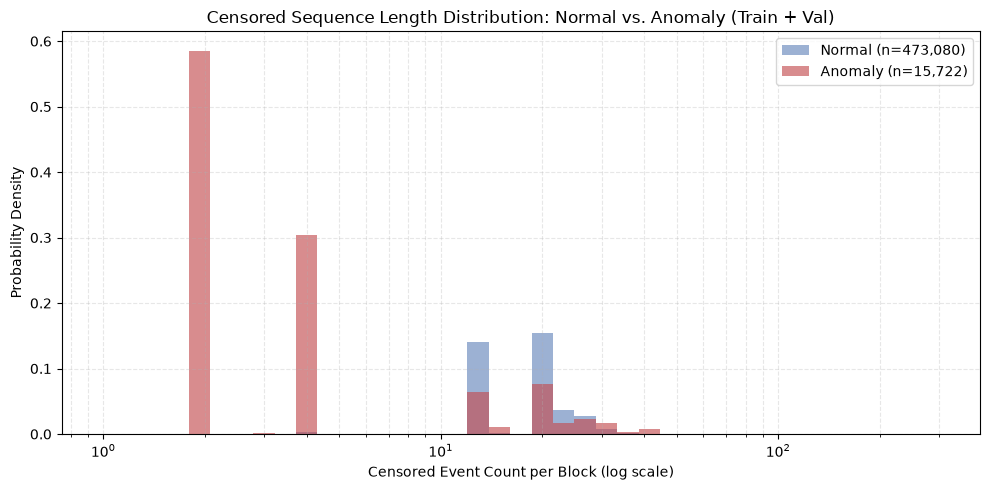


Saved figure: figures/LOG_censored_event_count_by_label.png


In [6]:
import re
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

BLOCK_REGEX = re.compile(r"blk_-?\d+")
FIGURES_DIR = PROJECT_ROOT / config["paths"]["figures_dir"]
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# 1. Single streaming pass over HDFS.log to compute censored event lines and template sets
# Censoring rule:
# - train blocks only acquire events from [train_start_line, train_end_line]
# - val blocks only acquire events from [val_start_line, val_end_line]
# - lines outside a block's own split range are strictly censored
print("Extracting per-block censored events via streaming pass over HDFS.log...")

censored_event_counts = {b: 0 for b in scoped_blocks}
block_templates = {b: set() for b in scoped_blocks}

# Extract template series as numpy array for instant index lookup
template_arr = df_scoped_events["template_id"].to_numpy()

with open(RAW_LOG_PATH, "r", encoding="utf-8", errors="replace") as f:
    with tqdm(total=fit_eligible_lines, unit="lines", desc="Auditing block lifespans", mininterval=1.0) as pbar:
        for line_num, line in enumerate(f, start=1):
            if line_num > fit_eligible_lines:
                break

            unique_blks = set(BLOCK_REGEX.findall(line))
            t_id = template_arr[line_num - 1]

            for b in unique_blks:
                if b in train_block_ids:
                    if train_start_line <= line_num <= train_end_line:
                        censored_event_counts[b] += 1
                        block_templates[b].add(t_id)
                elif b in val_block_ids:
                    if val_start_line <= line_num <= val_end_line:
                        censored_event_counts[b] += 1
                        block_templates[b].add(t_id)

            pbar.update(1)

# 2. Join censored event counts with scoped labels
df_scoped_labels["censored_event_count"] = df_scoped_labels["block_id"].map(censored_event_counts)

normal_counts = df_scoped_labels.loc[df_scoped_labels["label"] == "Normal", "censored_event_count"].to_numpy()
anomaly_counts = df_scoped_labels.loc[df_scoped_labels["label"] == "Anomaly", "censored_event_count"].to_numpy()

# 3. Distributional summary statistics
print("\n--- Censored Event Count Distribution by Label ---")
print(f"{'Metric':<16} | {'Normal Blocks':<16} | {'Anomaly Blocks':<16}")
print("-" * 52)
for q, name in [(0, "Min"), (25, "25th percentile"), (50, "Median"), (75, "75th percentile"), 
                (95, "95th percentile"), (99, "99th percentile"), (100, "Max")]:
    n_val = np.percentile(normal_counts, q)
    a_val = np.percentile(anomaly_counts, q)
    print(f"{name:<16} | {n_val:<16.1f} | {a_val:<16.1f}")
print(f"{'Mean':<16} | {normal_counts.mean():<16.2f} | {anomaly_counts.mean():<16.2f}")

# 4. Generate comparison visualization
fig, ax = plt.subplots(figsize=(10, 5))

# Log-scale histogram bins
min_val = max(1, min(normal_counts.min(), anomaly_counts.min()))
max_val = max(normal_counts.max(), anomaly_counts.max())
bins = np.logspace(np.log10(min_val), np.log10(max_val), 40)

ax.hist(normal_counts, bins=bins, density=True, alpha=0.55, color="#4C72B0", label=f"Normal (n={len(normal_counts):,})")
ax.hist(anomaly_counts, bins=bins, density=True, alpha=0.65, color="#C44E52", label=f"Anomaly (n={len(anomaly_counts):,})")

ax.set_xscale("log")
ax.set_xlabel("Censored Event Count per Block (log scale)")
ax.set_ylabel("Probability Density")
ax.set_title("Censored Sequence Length Distribution: Normal vs. Anomaly (Train + Val)")
ax.legend(frameon=True)
ax.grid(axis="x", which="both", linestyle="--", alpha=0.3)
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()

fig_path_len = FIGURES_DIR / "LOG_censored_event_count_by_label.png"
plt.savefig(fig_path_len, dpi=150)
plt.show()

print(f"\nSaved figure: {fig_path_len.relative_to(PROJECT_ROOT)}")

#### Truncation Confound Check

Before accepting the low-count concentration among Anomaly blocks as a genuine
signal, its cause is investigated directly, since Section 1.5 established that
split-boundary censoring can truncate a block's true event history independently
of its label. This section checks whether low-censored-count blocks are
genuinely short-lived or are truncation artifacts whose true lifespan extends
well past their own split's boundary.

In [7]:
# Confound check: are low-censored-count blocks genuinely short-lived, or are they
# censoring-truncation artifacts (blocks that started near their split's boundary,
# whose true lifespan extends well past what was counted)?
df_merged = df_scoped_labels.merge(df_scoped_lifespans, on="block_id", how="left")
df_merged["raw_width"] = df_merged["last_line"] - df_merged["first_line"] + 1
df_merged["is_truncated"] = np.where(
    df_merged["split"] == "train",
    df_merged["last_line"] > train_end_line,
    df_merged["last_line"] > val_end_line
)

low_count_mask = df_merged["censored_event_count"] <= 5

print("--- Truncation Confound Check (censored_event_count <= 5) ---")
for lbl in ["Normal", "Anomaly"]:
    sub = df_merged[(df_merged["label"] == lbl) & low_count_mask]
    total_low = len(sub)
    truncated = sub["is_truncated"].sum()
    print(f"{lbl}: {total_low:,} blocks with censored_event_count<=5, "
          f"{truncated:,} ({truncated/total_low*100:.2f}%) are truncated by the split boundary")
    if total_low > 0:
        print(f"  Raw (uncensored) lifespan width -> median: {sub['raw_width'].median():.1f}, "
              f"mean: {sub['raw_width'].mean():.1f}, max: {sub['raw_width'].max():,}")

print("\n--- Overall Truncation Rate by Label (all censored_event_count values) ---")
for lbl in ["Normal", "Anomaly"]:
    sub = df_merged[df_merged["label"] == lbl]
    rate = sub["is_truncated"].mean() * 100
    print(f"{lbl}: {rate:.2f}% of blocks are truncated by their own split's boundary")

--- Truncation Confound Check (censored_event_count <= 5) ---
Normal: 777 blocks with censored_event_count<=5, 777 (100.00%) are truncated by the split boundary
  Raw (uncensored) lifespan width -> median: 501956.0, mean: 313017.6, max: 1,569,477
Anomaly: 5,407 blocks with censored_event_count<=5, 4 (0.07%) are truncated by the split boundary
  Raw (uncensored) lifespan width -> median: 284.0, mean: 470.5, max: 701,975

--- Overall Truncation Rate by Label (all censored_event_count values) ---
Normal: 16.52% of blocks are truncated by their own split's boundary
Anomaly: 19.57% of blocks are truncated by their own split's boundary


**Findings 3.3:**

Censored event count differs meaningfully between Normal and Anomaly blocks in
the lower tail: the 25th percentile is 13 for Normal versus 4 for Anomaly, and
the histogram shows a large mass of Anomaly blocks at very low counts
(approximately 58% near count=2, 30% near count=4-5), while medians converge (19
for both) and upper percentiles are comparable or slightly higher for Anomaly
(95th percentile 38 vs 28).

Before treating this low-count concentration as a real signal, its cause was
investigated directly, since Section 1.5 established that split-boundary
censoring can truncate a block's true event history. Among Anomaly blocks with
censored_event_count <= 5 (5,407 blocks, 34.4% of all Anomaly blocks), only
0.07% (4 blocks) are truncated by their own split's boundary; the remainder's
censored count is their true, complete event count. This confirms the low-count
concentration among Anomaly blocks is a genuine property of the data, not a
censoring artifact.

A separate, smaller confound was found on the Normal side: all 777 Normal
blocks with censored_event_count <= 5 (0.16% of all 473,080 Normal blocks) are
truncation artifacts, with a median raw (uncensored) lifespan of 501,956 lines;
their true event count is substantially understated by the censored figure.
This population is too small to materially affect the reported Normal-class
percentiles above, but is not negligible for any downstream use of
censored_event_count as a per-block feature, since these 777 blocks would
otherwise appear indistinguishable from genuinely short-lived blocks.

More broadly, 16.52% of Normal blocks and 19.57% of Anomaly blocks are
truncated by their own split's boundary to some degree, consistent with the
block-count-weighted average of the boundary-crossing rates established in
`01_split_boundary_audit.ipynb` Section 1.5 (11.28% at train/val, 41.51% at
val/test), confirming internal consistency between the two notebooks'
measurements. Phase 4 must explicitly decide how to treat truncated blocks when
constructing any length- or count-based feature: excluding them, flagging them
with an explicit indicator, or accepting the censored count as a deliberately
realistic simulation of the partial observation a live monitoring system would
have for a block still active at scoring time are all defensible options, but
the choice must be made and documented rather than left implicit.

### 3.4 Template Composition by Label

This section examines whether specific event templates are disproportionately associated with anomalous blocks, using the same censored per-block event scope established in Section 3.3. This is exploratory characterization, not feature selection: no threshold or ranking produced here is treated as a finalized feature engineering decision, which remains the explicit scope of `04_feature_engineering.ipynb`. Particular attention should be paid to whether any single low-frequency template (of the kind investigated in `02_log_parsing.ipynb` Section 2.3) turns out to occur almost exclusively within anomalous blocks; if so, this should be reported plainly as a strong candidate signal rather than downplayed, while also noting the risk that a signal this clean may not generalize as cleanly to the test split.

In [8]:
import json

# 1. Load fitted template dictionary from Phase 2
with open(TEMPLATE_DICT_PATH, "r", encoding="utf-8") as f:
    template_dict = json.load(f)

# 2. Calculate template occurrence proportions across classes
total_normal_blocks = len(normal_counts)
total_anomaly_blocks = len(anomaly_counts)

is_anomaly_map = dict(zip(df_scoped_labels["block_id"], df_scoped_labels["label"] == "Anomaly"))

template_stats = []
for t_id, info in template_dict.items():
    norm_has_t = 0
    anom_has_t = 0

    for b, t_set in block_templates.items():
        if t_id in t_set:
            if is_anomaly_map[b]:
                anom_has_t += 1
            else:
                norm_has_t += 1

    prop_norm = norm_has_t / total_normal_blocks
    prop_anom = anom_has_t / total_anomaly_blocks
    diff = prop_anom - prop_norm

    template_stats.append({
        "template_id": t_id,
        "pattern": info["template_pattern"],
        "train_val_matches": info["train_val_matches"],
        "normal_block_prop": prop_norm,
        "anomaly_block_prop": prop_anom,
        "delta": diff,
        "abs_delta": abs(diff)
    })

df_template_analysis = pd.DataFrame(template_stats)
df_template_analysis.sort_values(by="abs_delta", ascending=False, inplace=True)

# 3. Report top candidates
print("--- Top 15 Most Differentiating Templates by Class Occurrence ---")
print(f"{'TID':<5} | {'Norm Prop':<10} | {'Anom Prop':<10} | {'Delta':<10} | {'Matches':<10} | {'Pattern'}")
print("-" * 95)
for _, r in df_template_analysis.head(15).iterrows():
    print(f"{r['template_id']:<5} | {r['normal_block_prop']*100:<9.2f}% | {r['anomaly_block_prop']*100:<9.2f}% | "
          f"{r['delta']*100:<+9.2f}% | {r['train_val_matches']:<10,} | {r['pattern'][:45]}...")

# 4. Check for near-exclusive shortcut templates (>90% anomaly, ~0% normal)
suspicious_shortcuts = df_template_analysis[
    (df_template_analysis["anomaly_block_prop"] > 0.90) & 
    (df_template_analysis["normal_block_prop"] < 0.05)
]

print("\n--- Shortcut / Generalization Risk Audit ---")
if len(suspicious_shortcuts) > 0:
    print(f"[WARNING] Detected {len(suspicious_shortcuts)} templates with near-exclusive anomaly alignment (>90% Anom, <5% Norm):")
    for _, r in suspicious_shortcuts.iterrows():
        print(f"  {r['template_id']}: Anom={r['anomaly_block_prop']*100:.2f}%, Norm={r['normal_block_prop']*100:.2f}% ({r['pattern']})")
    print("Flagged for explicit scrutiny: Risk of over-indexing on experimental artifacts in Phase 4/5.")
else:
    print("No single template acts as a trivial deterministic shortcut (>90% Anomaly and <5% Normal).")

--- Top 15 Most Differentiating Templates by Class Occurrence ---
TID   | Norm Prop  | Anom Prop  | Delta      | Matches    | Pattern
-----------------------------------------------------------------------------------------------
E4    | 99.84    % | 65.45    % | -34.39   % | 1,448,895  | Received block <*> of size <*> from <*>...
E5    | 99.83    % | 65.45    % | -34.38   % | 1,460,553  | BLOCK* NameSystem.addStoredBlock: blockMap up...
E3    | 99.84    % | 65.61    % | -34.23   % | 1,449,106  | PacketResponder <*> for block <*> <*>...
E32   | 72.57    % | 45.06    % | -27.51   % | 1,178,202  | BLOCK* NameSystem.delete: <*> is added to inv...
E17   | 72.72    % | 49.81    % | -22.91   % | 1,183,385  | Deleting block <*> file <*>...
E33   | 0.05     % | 20.32    % | +20.28   % | 4,173      | Unexpected error trying to delete block <*>. ...
E6    | 0.19     % | 18.39    % | +18.20   % | 6,251      | Received block <*> src: <*> dest: <*> of size...
E7    | 0.19     % | 18.39    % | +18.2

#### Completion-Template Absence vs. Truncation Confound Check

Before accepting the E3/E4/E5 absence pattern as a genuine signal, its cause is
checked directly against truncation status, following the same discipline
applied in Section 3.3: a block missing these templates only because its
completion event fell outside its own split's censored range would be a
censoring artifact, not a property of the block itself.

In [9]:
# Confound check: does E3/E4/E5 absence correlate with split-boundary truncation,
# or does it hold even for Anomaly blocks whose censored window is their complete,
# untruncated lifespan?
completion_templates = {"E3", "E4", "E5"}

def has_completion(b):
    return len(block_templates[b] & completion_templates) > 0

df_merged["has_completion"] = df_merged["block_id"].map(has_completion)
anom_sub = df_merged[df_merged["label"] == "Anomaly"]

print("--- Completion-Template Absence vs. Truncation Status (Anomaly blocks) ---")
crosstab = anom_sub.groupby(["has_completion", "is_truncated"]).size().unstack(fill_value=0)
print(crosstab)

no_completion = anom_sub[~anom_sub["has_completion"]]
has_completion_sub = anom_sub[anom_sub["has_completion"]]
print(f"\nOf Anomaly blocks LACKING E3/E4/E5: {no_completion['is_truncated'].mean()*100:.2f}% are truncated")
print(f"Of Anomaly blocks WITH E3/E4/E5   : {has_completion_sub['is_truncated'].mean()*100:.2f}% are truncated")

--- Completion-Template Absence vs. Truncation Status (Anomaly blocks) ---
is_truncated    False  True 
has_completion              
False            5403      4
True             7242   3073

Of Anomaly blocks LACKING E3/E4/E5: 0.07% are truncated
Of Anomaly blocks WITH E3/E4/E5   : 29.79% are truncated


**Findings 3.4:**

Template occurrence proportions differ substantially between Normal and Anomaly
blocks for several templates. The single strongest and highest-volume signal was
not captured by the `suspicious_shortcuts` filter, which only tests for
near-exclusive presence in Anomaly blocks (>90% Anomaly, <5% Normal): it is the
near-*absence* of the block-completion templates E3, E4, and E5 ("PacketResponder
for block", "Received block...of size", "blockMap updated") in Anomaly blocks.
These three templates, each with over 1.44 million train+val matches, appear in
99.83-99.84% of Normal blocks but only 65.45-65.61% of Anomaly blocks — roughly a
third of Anomaly blocks show no evidence of completing their block lifecycle at
all. Given the fault-injection nature of this dataset, a failed or interrupted
block transfer is a highly plausible mechanism for this pattern.

Because Section 3.3 established that split-boundary truncation can distort
per-block observations, a confound check was performed before accepting this as
genuine: whether the absence of E3/E4/E5 correlates with truncation rather than
with a true incomplete lifecycle. Of the 5,407 Anomaly blocks lacking E3/E4/E5,
only 0.07% (4 blocks) are truncated by their own split's boundary; the remaining
99.93% observe their complete, untruncated lifespan and still show no completion
event. This confirms the absence is a genuine property of these blocks, not a
censoring artifact, and this population overlaps closely with the low-count
blocks identified in Section 3.3, providing a second, independent internal
consistency check between the two sections. Blocks that do carry a completion
template are truncated at a higher rate (29.79%), consistent with completion
events tending to occur later in a block's lifecycle and therefore being more
exposed to a nearby split boundary; this does not affect the conclusion above.

A second, previously-documented pattern reappears here: E11 and E12 (replication-
destination messages Drain could not merge due to its fixed-depth tree's
inability to handle variable-length token lists, per `02_log_parsing.ipynb`
Section 2.3) show a large occurrence-proportion gap (18.13% Anomaly vs. 0.18%
Normal), retroactively validating the Phase 2 decision not to force-merge that
pair to match the reference template count; doing so would have discarded this
signal.

The `suspicious_shortcuts` filter, as implemented, found no template meeting its
one-sided criterion (near-exclusive presence in Anomaly blocks); this is noted
as a limitation of that specific check rather than an absence of strong signal,
since the E3/E4/E5 absence pattern above is arguably the strongest single
finding in this section and was only surfaced by inspecting the full ranked
table rather than the filtered one. No feature selection decision is made here;
both patterns are carried forward to `04_feature_engineering.ipynb` as strong
candidates, along with the caveat that E3/E4/E5 absence, tied to this specific
fault-injection experiment's failure mode, may not generalize as a signal
beyond datasets sharing this experimental structure.

### 3.5 Template Frequency by Class (Comparison Chart)

This section produces a single visual complement to Section 3.4: a side-by-side or overlaid bar chart comparing each template's occurrence proportion in Normal versus Anomaly blocks, ordered consistently with the ranking established in Section 3.4. This is the only additional chart planned for this notebook; per the portfolio's discipline of using visuals only where they add genuine interpretive value, no further charts should be added here without a specific finding that warrants one.

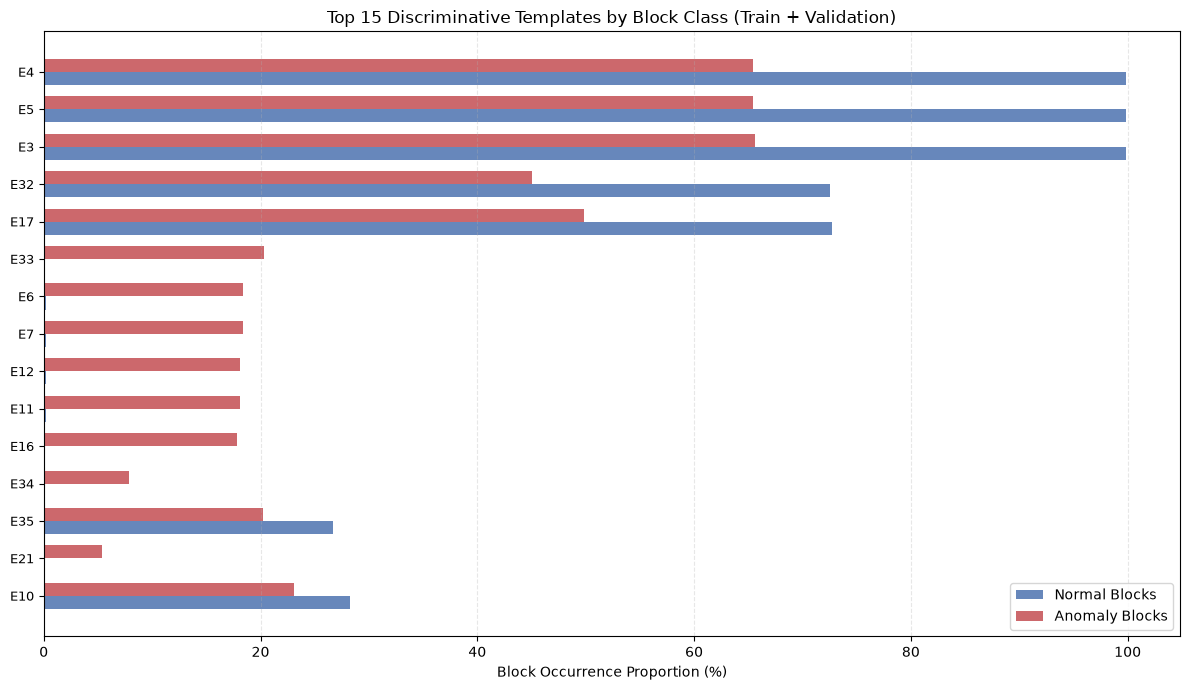

Saved figure: figures/LOG_template_occurrence_by_class.png


In [10]:
# Select top 15 differentiating templates for visual comparison
top_templates = df_template_analysis.head(15).iloc[::-1]  # Invert for horizontal readability

fig, ax = plt.subplots(figsize=(12, 7))

y_positions = np.arange(len(top_templates))
bar_height = 0.35

ax.barh(y_positions - bar_height / 2, top_templates["normal_block_prop"] * 100, height=bar_height,
        color="#4C72B0", label="Normal Blocks", alpha=0.85)
ax.barh(y_positions + bar_height / 2, top_templates["anomaly_block_prop"] * 100, height=bar_height,
        color="#C44E52", label="Anomaly Blocks", alpha=0.85)

ax.set_yticks(y_positions)
ax.set_yticklabels(top_templates["template_id"], fontsize=9)
ax.set_xlabel("Block Occurrence Proportion (%)")
ax.set_title("Top 15 Discriminative Templates by Block Class (Train + Validation)")
ax.legend(loc="lower right", frameon=True)
ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
fig_path_tpl = FIGURES_DIR / "LOG_template_occurrence_by_class.png"
plt.savefig(fig_path_tpl, dpi=150)
plt.show()

print(f"Saved figure: {fig_path_tpl.relative_to(PROJECT_ROOT)}")

**Findings 3.5:**

The comparison chart (`figures/LOG_template_occurrence_by_class.png`) visually
confirms the ranking established in Section 3.4 without altering its
interpretation: the completion-template absence pattern (E3, E4, E5) and the
Drain fixed-depth-tree pair (E11, E12) are both clearly visible as the largest
and most consistent gaps between Normal and Anomaly occurrence proportions. The
chart adds no new finding beyond Section 3.4; it is retained as the single
planned visual for this notebook, consistent with the project's discipline of
using charts only where they add interpretive value beyond the underlying table.

### 3.6 Phase 3 Summary

The label-safe scoping established in Section 3.1 held throughout this notebook:
488,802 train and validation blocks were loaded, joined, and analyzed, and at no
point was a test-split label or event row read into memory, including in the
implied-test-rate calculation in Section 3.2, which used only pre-published
aggregate totals rather than any per-block test label.

The class balance audit surfaced a material finding beyond simple train/val
consistency: train (3.26%) and validation (3.02%) are close to each other, but
both sit above the dataset-wide rate (2.93%), which arithmetically implies a
test-split anomaly rate of approximately 1.29%, less than half the combined
train+validation rate. This is documented as a deliberate characteristic of the
chronological split rather than a defect, and must be accounted for explicitly
when interpreting precision/recall and selecting a decision threshold in
`06_sealed_evaluation.ipynb`.

Two independent signal-bearing patterns were identified in block structure and
template composition, both validated against the truncation confound introduced
by split-boundary censoring (Section 1.5) before being accepted:

- **Censored event count** (Section 3.3): a large share of Anomaly blocks are
  very short (median count in the low single digits for roughly a third of
  Anomaly blocks), confirmed genuine rather than a censoring artifact for
  99.93% of the affected population. A separate, small population of 777
  Normal blocks (0.16% of all Normal blocks) was found to be a true truncation
  artifact and must be handled explicitly, not silently included, in Phase 4.
- **Completion-template absence** (Section 3.4): roughly a third of Anomaly
  blocks show no E3/E4/E5 (block-transfer completion) events, confirmed genuine
  for 99.93% of the affected blocks via the same confound check. The E11/E12
  pair also showed a strong occurrence-proportion gap, retroactively validating
  the Phase 2 decision not to force-merge that pair to match the reference
  template count.

The one-sided `suspicious_shortcuts` filter found no qualifying template, which
is noted as a limitation of that specific check rather than an absence of
strong signal: the strongest pattern found (completion-template absence) runs
in the opposite direction (under-representation in Anomaly, not over-
representation) and was only surfaced by inspecting the full ranked table.

On this basis, this phase is sound and complete enough to proceed to
`04_feature_engineering.ipynb`, which inherits three concrete candidate
features to formalize — censored event count (with an explicit truncation
flag), completion-template presence/absence, and the E11/E12 replication-
destination pattern — alongside the open decision of how truncated blocks
should be treated when these features are constructed. No test-split label or
event data was loaded anywhere in this notebook.